In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/dataset.csv")

In [ ]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Disease,0
Symptom_1,0
Symptom_2,0
Symptom_3,0
Symptom_4,348
Symptom_5,1206
Symptom_6,1986
Symptom_7,2652
Symptom_8,2976
Symptom_9,3228


In [ ]:
df.shape

(4920, 18)

In [ ]:
threshold = 0.5
columns_to_drop = [col for col in df.columns if df[col].isna().mean() > threshold]
df = df.drop(columns=columns_to_drop, axis=1)

In [ ]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Disease,0
Symptom_1,0
Symptom_2,0
Symptom_3,0
Symptom_4,348
Symptom_5,1206
Symptom_6,1986


In [ ]:
df['Symptom_4'] = df['Symptom_4'].fillna(df['Symptom_4'].mode()[0])
df['Symptom_5'] = df['Symptom_5'].fillna(df['Symptom_5'].mode()[0])
df['Symptom_6'] = df['Symptom_6'].fillna(df['Symptom_6'].mode()[0])


In [ ]:
df.isnull().sum()

,0
Disease,0
Symptom_1,0
Symptom_2,0
Symptom_3,0
Symptom_4,0
Symptom_5,0
Symptom_6,0


In [ ]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,headache,nausea
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,high_fever,headache,nausea
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,high_fever,headache,nausea
3,Fungal infection,itching,skin_rash,dischromic _patches,high_fever,headache,nausea
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,high_fever,headache,nausea


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
# we have no numerical columns, so we will not perform scaling or normalization.

In [ ]:
for col in categorical_cols:
    print(f"Unique values in {col}:")
    print(df[col].unique())

Unique values in Disease:
['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']
Unique values in Symptom_1:
['itching' ' skin_rash' ' continuous_sneezing' ' shivering'
 ' stomach_pain' ' acidity' ' vomiting' ' indigestion' ' muscle_wasting'
 ' patches_in_throat' ' fatigue' ' weight_loss' ' sunken_eyes' ' cough'
 ' headache' ' chest_pain' ' back_pain' ' weakness_in_limbs' ' chills

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Disease"] = le.fit_transform(df["Disease"])

In [ ]:
df_target = df["Disease"]
df_features = df.drop("Disease", axis=1)

In [ ]:
df["Disease"]

,Disease
0,15
1,15
2,15
3,15
4,15
...,...
4915,0
4916,2
4917,38
4918,35


In [ ]:
df_features = pd.get_dummies(df_features, columns=["Symptom_1", "Symptom_2", "Symptom_3", "Symptom_4", "Symptom_5", "Symptom_6"])

In [ ]:
df_features.head()

,Symptom_1_ acidity,Symptom_1_ back_pain,Symptom_1_ bladder_discomfort,Symptom_1_ breathlessness,Symptom_1_ burning_micturition,Symptom_1_ chest_pain,Symptom_1_ chills,Symptom_1_ constipation,Symptom_1_ continuous_sneezing,Symptom_1_ cough,...,Symptom_6_ painful_walking,Symptom_6_ prominent_veins_on_calf,Symptom_6_ puffy_face_and_eyes,Symptom_6_ stiff_neck,Symptom_6_ sweating,Symptom_6_ swelled_lymph_nodes,Symptom_6_ swollen_blood_vessels,Symptom_6_ unsteadiness,Symptom_6_ yellowing_of_eyes,Symptom_6_ yellowish_skin
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_features = df_features.astype(int)

In [ ]:
df_features.head()

,Symptom_1_ acidity,Symptom_1_ back_pain,Symptom_1_ bladder_discomfort,Symptom_1_ breathlessness,Symptom_1_ burning_micturition,Symptom_1_ chest_pain,Symptom_1_ chills,Symptom_1_ constipation,Symptom_1_ continuous_sneezing,Symptom_1_ cough,...,Symptom_6_ painful_walking,Symptom_6_ prominent_veins_on_calf,Symptom_6_ puffy_face_and_eyes,Symptom_6_ stiff_neck,Symptom_6_ sweating,Symptom_6_ swelled_lymph_nodes,Symptom_6_ swollen_blood_vessels,Symptom_6_ unsteadiness,Symptom_6_ yellowing_of_eyes,Symptom_6_ yellowish_skin
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_encoded = pd.concat([df_features, df_target], axis=1)
df_encoded.head()

,Symptom_1_ acidity,Symptom_1_ back_pain,Symptom_1_ bladder_discomfort,Symptom_1_ breathlessness,Symptom_1_ burning_micturition,Symptom_1_ chest_pain,Symptom_1_ chills,Symptom_1_ constipation,Symptom_1_ continuous_sneezing,Symptom_1_ cough,...,Symptom_6_ prominent_veins_on_calf,Symptom_6_ puffy_face_and_eyes,Symptom_6_ stiff_neck,Symptom_6_ sweating,Symptom_6_ swelled_lymph_nodes,Symptom_6_ swollen_blood_vessels,Symptom_6_ unsteadiness,Symptom_6_ yellowing_of_eyes,Symptom_6_ yellowish_skin,Disease
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15


In [ ]:
X = df_encoded.drop("Disease", axis=1)
y = df_encoded["Disease"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(3936, 256)

In [ ]:
y_train.shape

(3936,)

In [ ]:
X_test.shape

(984, 256)

In [ ]:
y_test.shape

(984,)

In [ ]:
df["Disease"].nunique()

41

In [ ]:
def initialise_centroids(X, k, seed=42):
    np.random.seed(seed)
    m = X.shape[0]
    indices = np.random.choice(m, size=k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k, old_centroids):
    n_features = X.shape[1]
    new_centroids = np.zeros((k, n_features))

    for i in range(k):
        points_in_cluster = X[labels == i]

        if len(points_in_cluster) > 0:
            new_centroids[i] = points_in_cluster.mean(axis=0)
        else:
            # The fix: Ensure we are using the correct reference
            # If this still fails, it means old_centroids was initialized with the wrong k
            new_centroids[i] = old_centroids[i]

    return new_centroids



In [ ]:

def kmeans(X, k, max_iters=100, seed=42):
    # This MUST create k centroids.
    # If k=5, centroids must have shape (5, n_features)
    centroids = initialise_centroids(X, k, seed=seed)

    for i in range(max_iters):
        labels = assign_clusters(X, centroids)
        # Pass the current 'centroids' (which has k rows) as 'old_centroids'
        new_centroids = update_centroids(X, labels, k, centroids)

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    # 5. Calculate Inertia (Within-Cluster Sum of Squares)
    # Sum of squared Euclidean distances of each point to its assigned centroid
    # Hint: We can reuse the logic from assign_clusters to get distances
    dist_matrix = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    # Pick the distance to the assigned centroid for each point and square it
    assigned_distances = dist_matrix[np.arange(len(X)), labels]
    inertia = np.sum(assigned_distances**2)

    return labels, centroids, inertia, i + 1

def elbow_plot(X, k_range=range(1, 11)):
    """
    Run K-Means for each k in k_range, collect inertia, plot elbow curve.
    """
    inertias = []

    for k in k_range:
        # We only need the inertia from our kmeans function
        _, _, inertia, _ = kmeans(X, k, seed=42)
        inertias.append(inertia)

    # Plotting the Elbow Curve
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertias, marker='o', linestyle='--', color='b')

    # Formatting the plot
    plt.title('The Elbow Method for Optimal k', fontsize=14)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
    plt.xticks(k_range)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Annotating the likely elbow (optional)
    plt.annotate('Potential Elbow', xy=(5, inertias[4]), xytext=(6, inertias[4] + 100),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.show()

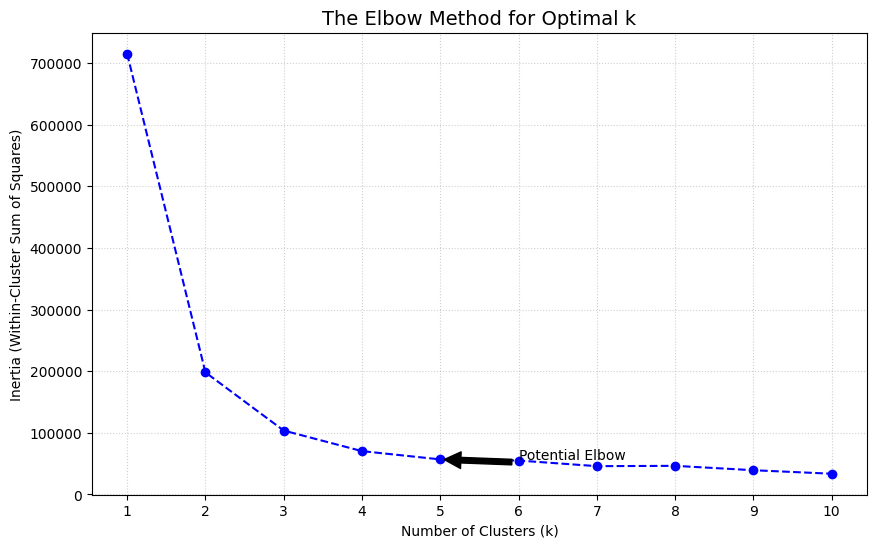

K-Means | k=5 | inertia=56816.9164 | iters=20


In [ ]:
X = df_encoded.values
elbow_plot(X)
labels, centroids, inertia, n_iters = kmeans(X, k=5)
print(f'K-Means | k=5 | inertia={inertia:.4f} | iters={n_iters}')

In [ ]:
print("Final Cluster Assignments (labels):")
print(labels)
print("\nFinal Cluster Centroids:")
print(centroids)

Final Cluster Assignments (labels):
[0 0 0 ... 2 2 4]

Final Cluster Centroids:
[[6.25000000e-03 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.55000000e+01]
 [0.00000000e+00 1.50000000e-01 0.00000000e+00 ... 5.00000000e-02
  0.00000000e+00 8.50000000e+00]
 [8.63636364e-02 0.00000000e+00 9.09090909e-03 ... 0.00000000e+00
  0.00000000e+00 3.50000000e+01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 2.50000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  7.00000000e-02 2.45000000e+01]]


In [ ]:
df_results = pd.DataFrame({'Cluster': labels, 'True_Label': y})

print("\nCluster Analysis:")
for cluster_id in sorted(df_results['Cluster'].unique()):
    cluster_data = df_results[df_results['Cluster'] == cluster_id]

    # Check if cluster_data is empty before proceeding
    if cluster_data.empty:
        print(f"Cluster {cluster_id}: No data points in this cluster.")
        continue

    total_in_cluster = len(cluster_data)

    # Find the most frequent true label in this cluster
    if not cluster_data['True_Label'].empty:
        most_frequent_label = cluster_data['True_Label'].mode()[0] # .mode() returns a Series, take the first if multiple modes
        count_most_frequent = (cluster_data['True_Label'] == most_frequent_label).sum()
        percentage = (count_most_frequent / total_in_cluster) * 100
        print(f"Cluster {cluster_id}: Most frequent true label is {most_frequent_label} ({percentage:.2f}% of rows in this cluster).")
    else:
        print(f"Cluster {cluster_id}: No true labels found for data points in this cluster.")


Cluster Analysis:
Cluster 0: Most frequent true label is 12 (12.50% of rows in this cluster).
Cluster 1: Most frequent true label is 6 (16.67% of rows in this cluster).
Cluster 2: Most frequent true label is 30 (9.09% of rows in this cluster).
Cluster 3: Most frequent true label is 0 (16.67% of rows in this cluster).
Cluster 4: Most frequent true label is 20 (10.00% of rows in this cluster).


In [ ]:
from sklearn.metrics import silhouette_score
print(f'Silhouette Score: {silhouette_score(X, labels):.4f}')

Silhouette Score: 0.4246


In [ ]:
def compute_distance_matrix(X):

    # X has shape (n, d)
    # 1. Expand X into two different dimensions to trigger broadcasting
    # X[:, np.newaxis, :] has shape (n, 1, d)
    # X[np.newaxis, :, :] has shape (1, n, d)
    # Subtracting them results in a shape (n, n, d)
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]

    # 2. Compute the Euclidean norm across the feature dimension (axis 2)
    # This calculates sqrt(sum(diff^2)) for every pair (i, j)
    dist_matrix = np.linalg.norm(diff, axis=2)

    return dist_matrix

In [ ]:

def kmedoid(X, k, max_iters=100, seed=42):
    np.random.seed(seed)
    n = X.shape[0]

    # 1. Compute full distance matrix once
    D = compute_distance_matrix(X)

    # 2. Initialize: Randomly select k row indices as medoids
    medoid_indices = np.random.choice(n, k, replace=False)

    # Function to calculate total cost and labels based on current medoids
    def calculate_assignment(current_medoids):
        # Extract distances from every point to the k medoids
        dist_to_medoids = D[:, current_medoids]
        # Assign to nearest medoid index (0 to k-1)
        labels = np.argmin(dist_to_medoids, axis=1)
        # Total cost is the sum of distances to the nearest medoid
        total_cost = np.sum(np.min(dist_to_medoids, axis=1))
        return labels, total_cost

    labels, total_cost = calculate_assignment(medoid_indices)

    # 3. Swap Phase
    for _ in range(max_iters):
        improved = False

        for m_idx in range(k): # For each medoid
            for o in range(n): # For each point in the dataset
                if o in medoid_indices:
                    continue

                # Try swapping current medoid with point o
                new_medoids = medoid_indices.copy()
                new_medoids[m_idx] = o

                _, new_cost = calculate_assignment(new_medoids)

                # 4. If cost decreases, keep the swap
                if new_cost < total_cost:
                    total_cost = new_cost
                    medoid_indices = new_medoids
                    improved = True

        # If no swap improved the cost in a full pass, we've converged
        if not improved:
            break

    # Final assignment
    labels, total_cost = calculate_assignment(medoid_indices)

    return labels, medoid_indices, total_cost

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=50):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None

    def _step_function(self, x):
        return 1 if x > 0 else 0

    def fit(self, X, y):
        # 1. Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        self.training_accuracies = []

        for epoch in range(self.n_epochs):
            correct_predictions = 0
            for idx, x_i in enumerate(X):
                # 2. Compute weighted sum
                linear_output = np.dot(x_i, self.weights) + self.bias
                # 3. Apply step activation function
                y_predicted = self._step_function(linear_output)

                # 4. Compute error
                error = y[idx] - y_predicted

                # 5. Update weights and bias
                self.weights += self.learning_rate * error * x_i
                self.bias += self.learning_rate * error

                if y_predicted == y[idx]:
                    correct_predictions += 1

            # Record training accuracy after each epoch
            accuracy = correct_predictions / n_samples
            self.training_accuracies.append(accuracy)
            # print(f"Epoch {epoch+1}/{self.n_epochs}, Accuracy: {accuracy:.4f}")

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self._step_function(x) for x in linear_output])

### Training the Perceptron and Plotting Accuracy

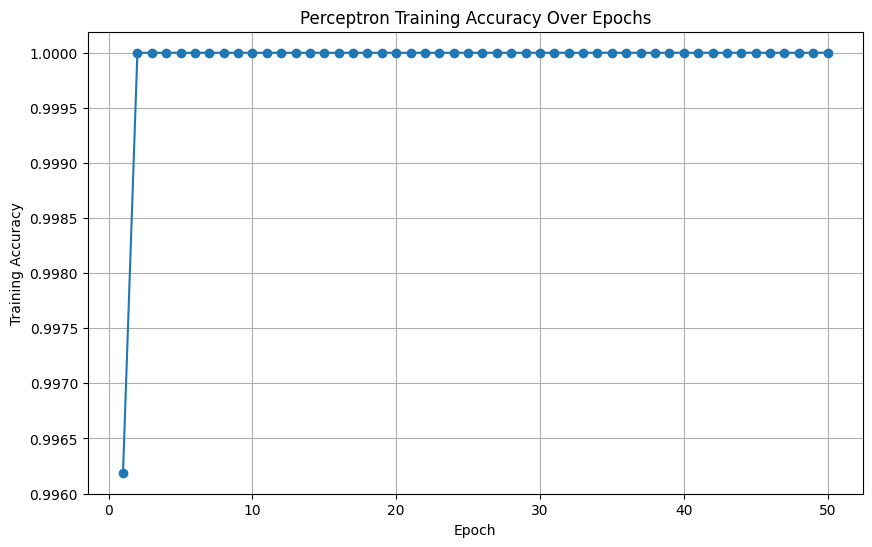

Test Accuracy: 1.0000


In [ ]:
# Instantiate and train the Perceptron
# Note: The Perceptron is a binary classifier, but our target 'y' (Disease) has 41 classes.
# For demonstration, we'll simplify the problem to a binary classification.
# Let's say we want to classify 'Fungal infection' (encoded as 15) vs. all others.

y_binary_train = (y_train == 15).astype(int)
y_binary_test = (y_test == 15).astype(int)

perceptron = Perceptron(learning_rate=0.01, n_epochs=50)
perceptron.fit(X_train.values, y_binary_train.values)

# Plot the training accuracy over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, perceptron.n_epochs + 1), perceptron.training_accuracies, marker='o')
plt.title('Perceptron Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.grid(True)
plt.show()

# Evaluate on test set
test_predictions = perceptron.predict(X_test.values)
test_accuracy = np.sum(test_predictions == y_binary_test.values) / len(y_binary_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

### Step 4: Delta Rule and Gradient Descent

In [ ]:
class DeltaRule:
    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.mse_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # 1. Initialize weights as random small values
        self.weights = np.random.randn(n_features) * 0.01 # Small random values
        self.bias = np.random.randn() * 0.01 # Small random bias

        for epoch in range(self.n_epochs):
            # Initialize gradients for batch update
            weight_gradient = np.zeros(n_features)
            bias_gradient = 0
            total_error_squared = 0

            for idx, x_i in enumerate(X):
                # 2. Compute the linear output
                linear_output = np.dot(x_i, self.weights) + self.bias

                # 3. Compute the error
                error = y[idx] - linear_output
                total_error_squared += error**2

                # Accumulate gradients (Delta Rule: error * input for weights, error for bias)
                weight_gradient += error * x_i
                bias_gradient += error

            # 5. Implement batch gradient descent: compute the average weight update
            # and update weights and bias once per epoch
            self.weights += self.learning_rate * (weight_gradient / n_samples)
            self.bias += self.learning_rate * (bias_gradient / n_samples)

            # Record the mean squared error after each epoch
            mse = total_error_squared / n_samples
            self.mse_history.append(mse)
            # print(f"Epoch {epoch+1}/{self.n_epochs}, MSE: {mse:.4f}")

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        # For comparison with Perceptron, we can still threshold, or use as a regression output
        # For this context, assuming a binary output is still desired, but the model learns linearly
        return linear_output

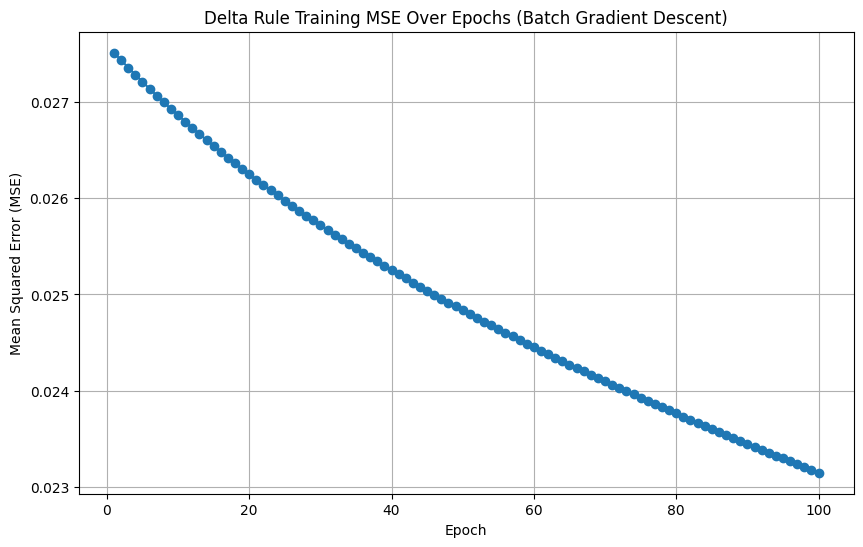

In [ ]:
# Instantiate and train the DeltaRule model
delta_rule_model = DeltaRule(learning_rate=0.01, n_epochs=100)
delta_rule_model.fit(X_train.values, y_binary_train.values)

# Plot the training MSE over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, delta_rule_model.n_epochs + 1), delta_rule_model.mse_history, marker='o')
plt.title('Delta Rule Training MSE Over Epochs (Batch Gradient Descent)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

### Comparison of Perceptron and Delta Rule Convergence

The Perceptron algorithm updates weights only when a misclassification occurs and uses a step activation function. Its convergence is guaranteed for linearly separable data, and it aims to find *any* separating hyperplane.

The Delta Rule, on the other hand, uses a linear activation function and updates weights based on the continuous error (difference between true and predicted linear output). It minimizes the Mean Squared Error (MSE) using gradient descent, aiming to find the *best* linear fit to the data, even if it's not perfectly separable. Therefore, its `mse_history` plot shows a continuous decrease as it approaches the minimum of the MSE surface.

To compare convergence speed, we observe the number of epochs it takes for each model's metric (accuracy for Perceptron, MSE for Delta Rule) to stabilize or reach a satisfactory level. The Perceptron's accuracy might fluctuate more and then stabilize, while the Delta Rule's MSE will generally show a smoother, more gradual decrease towards a minimum.

### Step 5: Multilayer Perceptron (MLP) with Backpropagation

First, let's define the activation functions: ReLU for hidden layers and Softmax for the output layer (since we have multiple classes).

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    # Subtract max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2


Now, let's implement the `MLP` class with the specified architecture and forward propagation logic.

**Network Architecture:**
*   **Input Layer**: `X_train.shape[1]` features
*   **Hidden Layer 1**: 16 neurons, ReLU activation
*   **Hidden Layer 2**: 8 neurons, ReLU activation
*   **Output Layer**: `y_train.nunique()` classes, Softmax activation

In [ ]:
class MLP:
    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size, seed=42):
        np.random.seed(seed)

        # Initialize weights and biases for Hidden Layer 1
        self.W1 = np.random.randn(input_size, hidden_size_1) * 0.01
        self.b1 = np.zeros((1, hidden_size_1))

        # Initialize weights and biases for Hidden Layer 2
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.01
        self.b2 = np.zeros((1, hidden_size_2))

        # Initialize weights and biases for Output Layer
        self.W3 = np.random.randn(hidden_size_2, output_size) * 0.01
        self.b3 = np.zeros((1, output_size))

        self.params = {
            'W1': self.W1, 'b1': self.b1,
            'W2': self.W2, 'b2': self.b2,
            'W3': self.W3, 'b3': self.b3
        }

    def forward(self, X):
        # Layer 1: Input to Hidden 1
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1) # Apply ReLU activation

        # Layer 2: Hidden 1 to Hidden 2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = relu(self.Z2) # Apply ReLU activation

        # Layer 3: Hidden 2 to Output
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = softmax(self.Z3) # Apply Softmax activation

        return self.A3


Let's demonstrate the forward pass with our training data. We need to convert `y_train` to one-hot encoding for the output layer, as Softmax outputs probabilities for each class.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Get dimensions for the MLP
input_size = X_train.shape[1]
hidden_size_1 = 16
hidden_size_2 = 8
output_size = y_train.nunique()

# Instantiate the MLP model
mlp_model = MLP(input_size, hidden_size_1, hidden_size_2, output_size)

# Perform a forward pass
predictions = mlp_model.forward(X_train.values)

print("Shape of input data (X_train):", X_train.shape)
print("Shape of output predictions (probabilities for each class):", predictions.shape)
print("First 5 predictions (probabilities):")
print(predictions[:5])


Shape of input data (X_train): (3936, 256)
Shape of output predictions (probabilities for each class): (3936, 41)
First 5 predictions (probabilities):
[[0.0243901  0.02439032 0.02439051 0.02439036 0.02439022 0.02439014
  0.02439008 0.02439035 0.02438996 0.02439017 0.02439017 0.02439017
  0.02439069 0.02439038 0.02439048 0.02439013 0.02438997 0.02439045
  0.02439007 0.02439032 0.02439037 0.0243901  0.02439011 0.02439065
  0.02439015 0.02438999 0.0243904  0.0243903  0.02439035 0.02438976
  0.0243904  0.02439002 0.02439017 0.02439039 0.02439039 0.02439016
  0.0243903  0.0243901  0.02439037 0.02439022 0.0243903 ]
 [0.02438995 0.02439033 0.02439059 0.02439031 0.02439028 0.02439023
  0.02438992 0.02439049 0.0243901  0.02439032 0.02438992 0.02438999
  0.02439051 0.02439016 0.02439051 0.02439021 0.02438986 0.0243904
  0.02439011 0.02439036 0.02439023 0.02438992 0.02439026 0.02439066
  0.02439032 0.02439021 0.02439044 0.02439027 0.02439027 0.02439001
  0.02439027 0.02439043 0.02439006 0.0243905

### Helper Functions for MLP Training

In [ ]:
def _to_one_hot(y, num_classes):
    """Converts a class vector (integers) to binary class matrix (one-hot encoding)."""
    num_samples = len(y)
    one_hot = np.zeros((num_samples, num_classes))
    one_hot[np.arange(num_samples), y] = 1
    return one_hot

def cross_entropy_loss(y_true, y_pred):
    """Calculates the categorical cross-entropy loss."""
    num_samples = y_true.shape[0]
    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
    # Compute loss for each sample and average
    loss = -np.sum(y_true * np.log(y_pred)) / num_samples
    return loss

def calculate_accuracy(y_true_labels, y_pred_probabilities):
    """Calculates accuracy given true labels and predicted probabilities."""
    y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
    return np.mean(y_true_labels == y_pred_labels)


### Updating the MLP Class with Training and Backpropagation

In [ ]:
class MLP:
    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size, seed=42):
        np.random.seed(seed)

        # Initialize weights and biases for Hidden Layer 1
        self.W1 = np.random.randn(input_size, hidden_size_1) * 0.01
        self.b1 = np.zeros((1, hidden_size_1))

        # Initialize weights and biases for Hidden Layer 2
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.01
        self.b2 = np.zeros((1, hidden_size_2))

        # Initialize weights and biases for Output Layer
        self.W3 = np.random.randn(hidden_size_2, output_size) * 0.01
        self.b3 = np.zeros((1, output_size))

        self.params = {
            'W1': self.W1, 'b1': self.b1,
            'W2': self.W2, 'b2': self.b2,
            'W3': self.W3, 'b3': self.b3
        }
        self.output_size = output_size

    def forward(self, X):
        # Layer 1: Input to Hidden 1
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1) # Apply ReLU activation

        # Layer 2: Hidden 1 to Hidden 2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = relu(self.Z2) # Apply ReLU activation

        # Layer 3: Hidden 2 to Output
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = softmax(self.Z3) # Apply Softmax activation

        return self.A3

    def backward(self, X, y_true_one_hot, y_pred):
        num_samples = X.shape[0]

        # Backpropagate through Output Layer
        # Gradient of loss w.r.t. Z3 (for Softmax + Cross-Entropy)
        dZ3 = y_pred - y_true_one_hot
        dW3 = np.dot(self.A2.T, dZ3) / num_samples
        db3 = np.sum(dZ3, axis=0, keepdims=True) / num_samples

        # Backpropagate through Hidden Layer 2
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * relu_derivative(self.Z2)
        dW2 = np.dot(self.A1.T, dZ2) / num_samples
        db2 = np.sum(dZ2, axis=0, keepdims=True) / num_samples

        # Backpropagate through Hidden Layer 1
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / num_samples
        db1 = np.sum(dZ1, axis=0, keepdims=True) / num_samples

        return dW1, db1, dW2, db2, dW3, db3

    def fit(self, X_train, y_train, X_test, y_test, learning_rate=0.01, n_epochs=200, verbose=True):
        self.loss_history = []
        self.train_accuracy_history = []
        self.test_accuracy_history = []

        y_train_one_hot = _to_one_hot(y_train, self.output_size)
        y_test_one_hot = _to_one_hot(y_test, self.output_size) # for consistent loss calc, though accuracy uses labels

        for epoch in range(n_epochs):
            # Forward pass
            y_pred_train = self.forward(X_train)

            # Compute loss and accuracy
            loss = cross_entropy_loss(y_train_one_hot, y_pred_train)
            train_accuracy = calculate_accuracy(y_train, y_pred_train)

            # Backpropagation
            dW1, db1, dW2, db2, dW3, db3 = self.backward(X_train, y_train_one_hot, y_pred_train)

            # Update weights and biases
            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2
            self.W3 -= learning_rate * dW3
            self.b3 -= learning_rate * db3

            # Record metrics every 10 epochs
            if (epoch + 1) % 10 == 0 or epoch == 0:
                y_pred_test = self.forward(X_test)
                test_accuracy = calculate_accuracy(y_test, y_pred_test)

                self.loss_history.append(loss)
                self.train_accuracy_history.append(train_accuracy)
                self.test_accuracy_history.append(test_accuracy)
                if verbose:
                    print(f"Epoch {epoch + 1}/{n_epochs} | Loss: {loss:.4f} | Train Acc: {train_accuracy:.4f} | Test Acc: {test_accuracy:.4f}")

    def predict(self, X):
        # Perform forward pass and return predicted class labels
        probabilities = self.forward(X)
        return np.argmax(probabilities, axis=1)


### Training the MLP Model

Epoch 1/200 | Loss: 3.7136 | Train Acc: 0.0025 | Test Acc: 0.0102
Epoch 10/200 | Loss: 3.7136 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 20/200 | Loss: 3.7136 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 30/200 | Loss: 3.7136 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 40/200 | Loss: 3.7136 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 50/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 60/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 70/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 80/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 90/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 100/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 110/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 120/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 130/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc: 0.0152
Epoch 140/200 | Loss: 3.7135 | Train Acc: 0.0267 | Test Acc

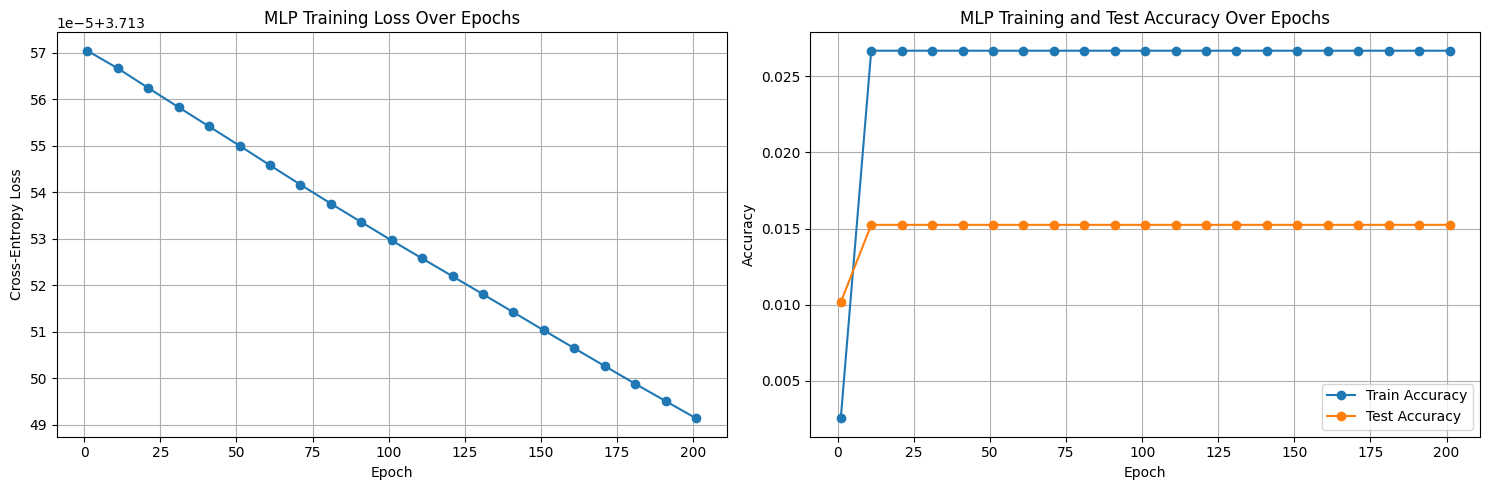

Final MLP Test Accuracy: 0.0152


In [ ]:
# Get dimensions for the MLP
input_size = X_train.shape[1]
hidden_size_1 = 16
hidden_size_2 = 8
output_size = y_train.nunique()

# Instantiate the MLP model
mlp_model = MLP(input_size, hidden_size_1, hidden_size_2, output_size)

# Train the MLP model
mlp_model.fit(X_train.values, y_train.values, X_test.values, y_test.values, learning_rate=0.01, n_epochs=200)

# Plotting Loss and Accuracy over Epochs
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(mlp_model.loss_history) * 10 + 1, 10), mlp_model.loss_history, marker='o')
plt.title('MLP Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(mlp_model.train_accuracy_history) * 10 + 1, 10), mlp_model.train_accuracy_history, label='Train Accuracy', marker='o')
plt.plot(range(1, len(mlp_model.test_accuracy_history) * 10 + 1, 10), mlp_model.test_accuracy_history, label='Test Accuracy', marker='o')
plt.title('MLP Training and Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Final evaluation
final_test_predictions = mlp_model.predict(X_test.values)
final_test_accuracy = np.mean(final_test_predictions == y_test.values)
print(f"Final MLP Test Accuracy: {final_test_accuracy:.4f}")


### Step 6: Compare All Models

To compare all models, we'll evaluate each one on the test set and record their performance. For K-Means, which is an unsupervised algorithm, we'll measure **cluster purity** instead of accuracy.

**Cluster Purity for K-Means:**
Cluster purity measures how "pure" the clusters are with respect to the true class labels. For each cluster, we find the majority class among its members and count how many members belong to that class. The sum of these counts across all clusters, divided by the total number of data points, gives the overall purity.

Let's calculate the cluster purity for our K-Means result:


In [ ]:
from collections import Counter

def calculate_cluster_purity(true_labels, cluster_labels):
    """
    Calculates the cluster purity for K-Means results.
    Args:
        true_labels (np.array): Array of true class labels.
        cluster_labels (np.array): Array of cluster assignments from K-Means.
    Returns:
        float: The purity score.
    """
    total_samples = len(true_labels)
    if total_samples == 0: return 0.0

    unique_clusters = np.unique(cluster_labels)
    purity = 0.0

    for cluster_id in unique_clusters:
        # Get true labels for points in the current cluster
        cluster_member_true_labels = true_labels[cluster_labels == cluster_id]

        if len(cluster_member_true_labels) > 0:
            # Find the most common true label in this cluster
            majority_label = Counter(cluster_member_true_labels).most_common(1)[0][0]
            # Count how many members match the majority label
            num_correct_assignments = np.sum(cluster_member_true_labels == majority_label)
            purity += num_correct_assignments

    return purity / total_samples

# Calculate K-Means purity on the full dataset X using the previously found labels
k_means_purity = calculate_cluster_purity(df_encoded['Disease'].values, labels)
print(f"K-Means Cluster Purity (k=5): {k_means_purity:.4f}")


K-Means Cluster Purity (k=5): 0.1220
